# Supplementary Figure 4 — Data-driven validation of the behavioral state taxonomy
Source: `_source_archive/by_figure/Fig6/07b_KMEANS_Final.ipynb` (same
underlying K-Means/HMM fit as Fig 6 -- this figure reports the supporting
model-selection curves and cluster/HMM mean tables that back Fig 6's
headline result).

**This notebook was rebuilt after cross-checking against the actual
submitted manuscript PDF** (`2026.06.30.734629v1.full (4).pdf`, Supp Fig 4
legend, ~page 33). The previous version reused the same "PUBLICATION
FIGURE" mega-functions as Fig 6 (a 4-panel silhouette/BIC/AIC/cluster-
heatmap figure, plus a 3-panel transition-matrix/emission-means/dwell-time
figure). Cross-checking against the manuscript found Supp Fig 4's real
panels a-c are simpler and narrower than either of those:
- **a** = silhouette + BIC/AIC curves only (no cluster heatmap) -- a
  1x2 line-plot figure.
- **b** = the K-means cluster-mean heatmap only.
- **c** = the HMM emission-means heatmap only -- NOT the transition
  matrix or dwell time, which are Fig 6's real panels d/e instead (this
  pipeline's earlier version had put all three -- transition matrix,
  emission means, dwell time -- here).
- **d** = behavioral metrics across the full **seven**-state taxonomy
  (Adapting fast/slow, Exploitation, Directed/Random Exploration, Left/
  Right Bias). This needs the full 7-state classifier, which is a
  separate, larger task another agent is building for Fig 7 -- **not
  built here**; see the explicit placeholder cell below.

See `src/plotting/state_taxonomy.py`'s module docstring for the full
before/after mapping, and `_source_archive/INDEX.md`'s Supp Fig 4 row.

In [1]:
import os
import sys
import json
import functools

sys.path.insert(0, os.path.abspath(".."))

from IPython.display import SVG, display

from src.io.load_snapshots import load_config, load_snapshot
from src.features import state_features
from src.behavior_metrics import state_classifier, state_clustering, state_taxonomy_v7 as sx7
from src.plotting.style import apply_style
from src.plotting import state_taxonomy as plotting

config = load_config()
apply_style(config)
cfg = config["state_taxonomy"]
DISPLAY_LABELS = cfg["display_labels"]
CLASSES_V3 = ["Engaged", "Exploration", "Left Bias", "Right Bias"]

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "SuppFig4")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {"_stage": "Supp Fig 4 -- model-selection curves + cluster/HMM mean tables backing Fig 6 (real panels a-c), plus panel d (behavioral metrics on the canonical 7-state taxonomy)"}


def show(path):
    display(SVG(path))

## Reconstruct state features and apply `classify_state_v3` (same as Fig 6)

In [2]:
df_raw = load_snapshot(config, cfg["input_files"]["reversal_80_20_2abt"])
df = state_features.build_state_features_df(df_raw, cfg["task_type"], cfg["prob_condition"], cfg["rolling_window"])
classify_v3 = functools.partial(state_classifier.classify_state_v3, config=cfg["classify_v3"])
df["Behavioral_State_v3"] = df.apply(classify_v3, axis=1)
df["States_Merged_v3"] = df["Behavioral_State_v3"].replace({"Left Bias": "Bias", "Right Bias": "Bias"})
manifest["n_trials"] = int(len(df))
manifest["n_sessions"] = int(df["Session_ID"].nunique())
manifest["n_animals"] = int(df["Animal_Name"].nunique())

train_sessions, test_sessions = state_clustering.train_test_split_sessions(
    df, cfg["train_test_split"]["test_size"], cfg["train_test_split"]["seed"]
)

/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/features/state_features.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df_filtered.groupby("Session_ID").apply(


## Panel a
**Manuscript legend:** *"Silhouette score (left) and Bayesian Information
Criterion (BIC) and Akaike Information Criterion (AIC) scores (right)
across K-means cluster solutions from K=2 to K=8."*

A small standalone 1x2 line-plot figure -- not the full K-Means
publication-figure mega-function this pipeline used to reuse here (that
function also drew a PCA scatter and cluster heatmap, which belong to Fig
6 panel b and this figure's own panel b, respectively).

Silhouette peak K=3, BIC minimum K=8, AIC minimum K=8
K-Means fit at K=4 (Fig 6's reported K, not the silhouette/BIC optimum -- both are reported here rather than hidden, per REVIEWER_AUDIT.md's finding that the source notebook hardcoded K=4 despite its own model-selection cell computing different optima)


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))


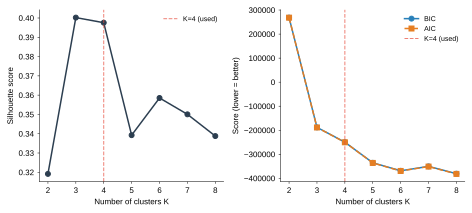

In [3]:
kmeans_result = state_clustering.run_kmeans_validation(
    df, "Behavioral_State_v3", CLASSES_V3,
    cfg["features"], train_sessions, test_sessions,
    cfg["kmeans"]["k_range"], cfg["kmeans"]["k_best"], cfg["train_test_split"]["seed"],
    config["state_taxonomy"]["pca_n_components"], config["state_taxonomy"]["pca_plot_subsample_per_session"],
)
print(f"Silhouette peak K={kmeans_result['best_k_silhouette']}, BIC minimum K={kmeans_result['best_k_bic']}, "
      f"AIC minimum K={kmeans_result['k_range'][kmeans_result['aic_by_k'].index(min(kmeans_result['aic_by_k']))]}")
print(f"K-Means fit at K={kmeans_result['k_used']} (Fig 6's reported K, not the silhouette/BIC optimum -- "
      f"both are reported here rather than hidden, per REVIEWER_AUDIT.md's finding that the source notebook "
      f"hardcoded K=4 despite its own model-selection cell computing different optima)")
manifest["kmeans_model_selection"] = {
    "k_range": kmeans_result["k_range"],
    "silhouette_by_k": kmeans_result["silhouette_by_k"],
    "bic_by_k": kmeans_result["bic_by_k"],
    "aic_by_k": kmeans_result["aic_by_k"],
    "best_k_silhouette": kmeans_result["best_k_silhouette"],
    "best_k_bic": kmeans_result["best_k_bic"],
    "k_used": kmeans_result["k_used"],
}

plotting.plot_kmeans_model_selection(kmeans_result, os.path.join(FIG_DIR, "panel_a_model_selection.svg"))
show(os.path.join(FIG_DIR, "panel_a_model_selection.svg"))

## Panel b
**Manuscript legend:** *"Mean feature values for each of four behavioral
clusters identified by K-Means clustering (K=4) applied to derived
behavioral features without reference to state labels. Signed Deviation,
the signed difference between an animal's choice probability and the
expected choice probability given block structure, served as the primary
feature distinguishing bias from non-bias states (blue box). Cluster
profiles were computed from train-set centroids and evaluated on held-out
sessions."*

A single small heatmap -- already have `cluster_profiles` from
`state_clustering.run_kmeans_validation` above, just need the dedicated
panel layout rather than the full publication-figure mega-function.

Cluster profiles (train centroids):
{'Engaged': {'Signed_Deviation': -0.0024, 'Choice_Deviation': 0.1721, 'Rolling_Accuracy': 0.785, 'Rolling_Switch_Rate': 0.0763}, 'Exploration': {'Signed_Deviation': -0.0061, 'Choice_Deviation': 0.1863, 'Rolling_Accuracy': 0.4616, 'Rolling_Switch_Rate': 0.4207}, 'Left Bias': {'Signed_Deviation': -0.6388, 'Choice_Deviation': 0.6388, 'Rolling_Accuracy': 0.3987, 'Rolling_Switch_Rate': 0.1649}, 'Right Bias': {'Signed_Deviation': 0.6441, 'Choice_Deviation': 0.6441, 'Rolling_Accuracy': 0.4197, 'Rolling_Switch_Rate': 0.1671}}


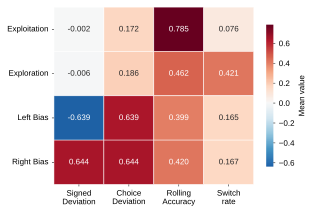

In [4]:
print("Cluster profiles (train centroids):")
print(kmeans_result["cluster_profiles"])
manifest["kmeans_cluster_profiles"] = kmeans_result["cluster_profiles"]
manifest["kmeans_pca_explained_variance"] = kmeans_result["pca_explained_variance"]

plotting.plot_kmeans_cluster_heatmap(
    kmeans_result, CLASSES_V3, DISPLAY_LABELS, os.path.join(FIG_DIR, "panel_b_cluster_heatmap.svg")
)
show(os.path.join(FIG_DIR, "panel_b_cluster_heatmap.svg"))

## Panel c
**Manuscript legend:** *"HMM emission means for each state in the
three-state solution, confirming the behavioral signatures of Bias (high
absolute deviation, low accuracy), Exploitation (high accuracy, near-zero
switching), and Exploration (moderate accuracy, high switching), derived
independently of the K-Means solution."*

A single small heatmap -- already have `emission_means` from
`state_clustering.run_hmm_validation`. The transition matrix and dwell
time this pipeline's HMM fit also produces are NOT part of this panel
(they moved to Fig 6's real panels d/e -- see that notebook).

HMM emission means:
{'Bias': {'Signed_Deviation': 0.7117, 'Choice_Deviation': 0.7118, 'Rolling_Accuracy': 0.4183, 'Rolling_Switch_Rate': 0.1445}, 'Engaged': {'Signed_Deviation': -0.0042, 'Choice_Deviation': 0.2, 'Rolling_Accuracy': 0.7962, 'Rolling_Switch_Rate': 0.0476}, 'Exploration': {'Signed_Deviation': -0.1394, 'Choice_Deviation': 0.2943, 'Rolling_Accuracy': 0.4887, 'Rolling_Switch_Rate': 0.3083}}


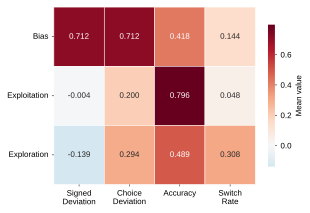

In [5]:
hmm_result = state_clustering.run_hmm_validation(
    df, "States_Merged_v3", "Behavioral_State_v3", cfg["features"], train_sessions, test_sessions,
    cfg["hmm"]["n_states"], cfg["hmm"]["n_trials_drop"], cfg["hmm"]["n_restarts"], cfg["train_test_split"]["seed"],
)
CLASSES_3 = hmm_result["classes_3"]
print("HMM emission means:")
print(hmm_result["emission_means"])
manifest["hmm_emission_means"] = hmm_result["emission_means"]

plotting.plot_hmm_emission_means(
    hmm_result, CLASSES_3, DISPLAY_LABELS, os.path.join(FIG_DIR, "panel_c_emission_means.svg")
)
show(os.path.join(FIG_DIR, "panel_c_emission_means.svg"))

## Panel d
**Manuscript legend:** *"Behavioral metrics by state classification
across seven behavioral states (Adapting fast, Adapting slow,
Exploitation, Directed Exploration, Random Exploration, Left Bias, Right
Bias). (top, left) probability of selecting the high probability choice,
(top, right) switch rate, (bottom, left) probability of selecting the
rightward option, (bottom, right) choice entropy (bits). Bars indicate
the mean across all animals; dots represent individual session
averages."*

Now unblocked: the canonical 7-state taxonomy (`classify_state_v7`) was
built for Fig 7 and is reused here unchanged, applied to the same `df`
reconstructed above for `classify_state_v3` (same task_type/prob_condition/
rolling_window as Fig 7 -- one dataset, two classifier columns, not a
second reconstruction). `Adapting_state_v7`/`Behavioral_State` here is a
distinct column from panels a-c's `Behavioral_State_v3` -- both coexist,
neither is overwritten.

`state_taxonomy_v7.state_behavioral_metrics_by_state` computes each of
the four metrics per (animal, session, state), then bars = mean of
per-animal means (this project's standing across-animal convention) and
dots = the raw per-session values themselves (per this panel's own
legend wording -- "dots represent individual session averages", not
per-animal averages as most of this project's other by-state panels use).
A `panel_d_min_trials_per_state_session` floor (5, same convention as Fig
6f's `wsls_min_trials_per_state_session`) drops (session, state) pairs
too sparse to give a stable estimate -- not tuned to any manuscript
number.

`Random Exploration` was previously reported as empty here -- that was a
bug (a `Rolling_Accuracy` reconstruction issue plus a branch-order swap
this pipeline had applied on `REVIEWER_AUDIT.md`'s recommendation), not a
real property of the design; see Fig 7's own notebook for the full
account. Both are now fixed, and `Random Exploration` shows up below with
real data (1,625 / 36,673 trials, 4.4%). The branch-order question itself
remains an open item the user is discussing with a co-author, not settled
here.

Behavioral_State
Exploit                 14167
Directed Exploration     8527
Adapting (slow)          4448
Adapting (fast)          4410
Left Bias                1728
Random Exploration       1625
Right Bias               1568
Unknown                   200
Name: count, dtype: int64

p_high_prob (mean +/- SEM across animals):
    Behavioral_State     mean      sem  n
     Adapting (fast) 0.722384 0.009231  5
     Adapting (slow) 0.291386 0.028140  5
Directed Exploration 0.648139 0.012037  5
             Exploit 0.937551 0.011457  5
           Left Bias 0.258311 0.018361  5
  Random Exploration 0.450597 0.015280  5
          Right Bias 0.249694 0.016421  5

switch_rate (mean +/- SEM across animals):
    Behavioral_State     mean      sem  n
     Adapting (fast) 0.204003 0.008926  5
     Adapting (slow) 0.223369 0.025251  5
Directed Exploration 0.297089 0.022558  5
             Exploit 0.062837 0.012194  5
           Left Bias 0.299964 0.015022  5
  Random Exploration 0.381863 0.024614  5

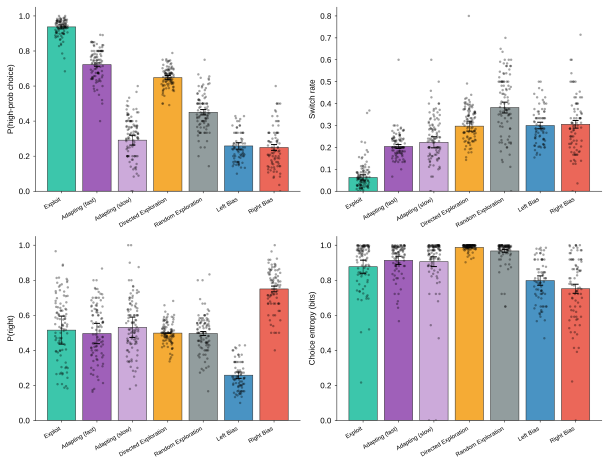

In [6]:
block_labels_v7 = state_classifier.label_block_adaptation_speed(
    df, cfg["adaptation_window"], cfg["adaptation_fast_accuracy_threshold"]
)
adaptation_labels_v7 = state_classifier.compute_adaptation_labels(
    df, cfg["adaptation_window"], cfg["adaptation_fast_accuracy_threshold"],
    block_labels=block_labels_v7,
)
classify_v7 = functools.partial(
    state_classifier.classify_state_v7, adaptation_labels=adaptation_labels_v7, config=cfg["classify_updated"]
)
df_v7 = df.copy()
df_v7["Behavioral_State"] = df_v7.apply(classify_v7, axis=1)
print(df_v7["Behavioral_State"].value_counts())
manifest["panel_d_state_distribution"] = df_v7["Behavioral_State"].value_counts().to_dict()

session_df_d, animal_df_d, summary_d = sx7.state_behavioral_metrics_by_state(
    df_v7, state_classifier.STATES_V7_ALL, min_trials=cfg["panel_d_min_trials_per_state_session"]
)
for metric in ["p_high_prob", "switch_rate", "p_right", "entropy_bits"]:
    print(f"\n{metric} (mean +/- SEM across animals):")
    print(summary_d[metric].to_string(index=False))
manifest["panel_d_metrics"] = {
    m: summary_d[m].set_index("Behavioral_State").to_dict(orient="index")
    for m in ["p_high_prob", "switch_rate", "p_right", "entropy_bits"]
}

out_d = os.path.join(FIG_DIR, "panel_d_behavioral_metrics.svg")
plotting.plot_panel_d_behavioral_metrics(
    session_df_d, summary_d, config["fig7"]["states_all_7_order"],
    config["plotting"]["state_colors_v7"], DISPLAY_LABELS, out_d
)
show(out_d)

## Values manifest

In [7]:
manifest_path = os.path.join(MANIFEST_DIR, "SuppFig4.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")
print(json.dumps(
    {k: v for k, v in manifest.items() if k not in ("kmeans_model_selection", "kmeans_cluster_profiles", "hmm_emission_means")},
    indent=2, default=str,
))


Saved values manifest: ../outputs/values_manifests/SuppFig4.json
{
  "_stage": "Supp Fig 4 -- model-selection curves + cluster/HMM mean tables backing Fig 6 (real panels a-c), plus panel d (behavioral metrics on the canonical 7-state taxonomy)",
  "n_trials": 36673,
  "n_sessions": 100,
  "n_animals": 5,
  "kmeans_pca_explained_variance": [
    0.3767704495483104,
    0.2829750573751601,
    0.24960085838282545
  ],
  "panel_d_state_distribution": {
    "Exploit": 14167,
    "Directed Exploration": 8527,
    "Adapting (slow)": 4448,
    "Adapting (fast)": 4410,
    "Left Bias": 1728,
    "Random Exploration": 1625,
    "Right Bias": 1568,
    "Unknown": 200
  },
  "panel_d_metrics": {
    "p_high_prob": {
      "Adapting (fast)": {
        "mean": 0.7223839775351871,
        "sem": 0.009231183349016056,
        "n": 5
      },
      "Adapting (slow)": {
        "mean": 0.2913859138001585,
        "sem": 0.02813970326459294,
        "n": 5
      },
      "Directed Exploration": {
     